In [36]:
# -*- coding: utf-8 -*-
import os
import shutil

# 1. CRÉATION DU DOSSIER /content (indispensable pour tes scripts qui cherchent ce chemin)
if not os.path.exists('/content'):
    !mkdir -p /content

# 2. NETTOYAGE
if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

# 3. CLONAGE
%cd /content
!GIT_LFS_SKIP_SMUDGE=1 git clone -b Vic https://github.com/SihamDaanouni/InstantMesh.git

# 4. INSTALLATION DES DÉPENDANCES MANQUANTES (Pour éviter l'erreur 'taming')
!pip install git+https://github.com/CompVis/taming-transformers.git

# 5. ENTRER DANS LE DOSSIER
%cd /content/InstantMesh

/content
Cloning into 'InstantMesh'...
remote: Enumerating objects: 393, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 393 (delta 159), reused 109 (delta 107), pack-reused 168 (from 2)
Receiving objects: 100% (393/393), 41.11 MiB | 42.14 MiB/s, done.
Resolving deltas: 100% (167/167), done.
  Cloning https://github.com/CompVis/taming-transformers.git to /tmp/pip-req-build-l3062e0x
  Running command git clone --filter=blob:none --quiet https://github.com/CompVis/taming-transformers.git /tmp/pip-req-build-l3062e0x
  Resolved https://github.com/CompVis/taming-transformers.git to commit 3ba01b241669f5ade541ce990f7650a3b8f65318
  Preparing metadata (setup.py) ... done
/content/InstantMesh


  Cloning https://github.com/CompVis/taming-transformers.git to /tmp/pip-req-build-0c67mex1
  Running command git clone --filter=blob:none --quiet https://github.com/CompVis/taming-transformers.git /tmp/pip-req-build-0c67mex1
  Resolved https://github.com/CompVis/taming-transformers.git to commit 3ba01b241669f5ade541ce990f7650a3b8f65318
  Preparing metadata (setup.py) ... done
  Created wheel for taming-transformers: filename=taming_transformers-0.0.1-py3-none-any.whl size=1115 sha256=cc5a8612ceb3adc5d58d54bc9e70dd9589f01a52bdfd90be4d071abde1c0ea10
  Stored in directory: /tmp/pip-ephem-wheel-cache-_jvu3typ/wheels/07/d2/62/308002498ad2a0c3161535d5ff138377509d9632bc78228dda
Successfully built taming-transformers


In [19]:
## INSTALLATION DES DÉPENDANCES

import os
import shutil

# 1. Préparation de l'espace /content
if not os.path.exists('/content'):
    !mkdir -p /content

# 2. Clonage de SyncDreamer
%cd /content
if os.path.exists('/content/SyncDreamer'):
    shutil.rmtree('/content/SyncDreamer')
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/liuyuan-pal/SyncDreamer

# --- AJOUT CRITIQUE POUR L'ERREUR TAMING ---
!pip install -q git+https://github.com/CompVis/taming-transformers.git
# -------------------------------------------

# 3. Installation des requirements de SyncDreamer
!pip install -r "/content/SyncDreamer/requirements.txt"

# 4. Fix numpy et utilitaires
!pip install -q "numpy<2.0.0"
!pip install -q onnxruntime-gpu ninja
!pip install -q PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg]

# 5. Machine Learning (Précision des versions pour éviter les conflits)
!pip install -q pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard

# 6. Variables CUDA
os.environ['CUDA_HOME'] = '/usr/local/cuda'
# On utilise une syntaxe plus sûre pour le PATH sur Kaggle
os.environ['PATH'] = os.environ.get('PATH', '') + ':/usr/local/cuda/bin'

# 7. nvdiffrast (indispensable pour le rendu 3D)
%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git
%cd /content/nvdiffrast
!pip install -q --no-build-isolation .

# 8. Nettoyage final et retour au dossier principal
!pip install -q "cupy-cuda12x<14.0.0"
!pip install -q peft==0.10.0

%cd /content/InstantMesh
print("\n=== INSTALLATION TERMINÉE ===")
print("Branche active :", end=" ")
!git branch --show-current

/content
Cloning into 'SyncDreamer'...
remote: Enumerating objects: 405, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 405 (delta 48), reused 32 (delta 31), pack-reused 341 (from 1)
Receiving objects: 100% (405/405), 83.54 MiB | 36.95 MiB/s, done.
Resolving deltas: 100% (112/112), done.
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/NVlabs/tiny-cuda-nn/ to /tmp/pip-req-build-cbtpm856
  Running command git clone --filter=blob:none --quiet https://github.com/NVlabs/tiny-cuda-nn/ /tmp/pip-req-build-cbtpm856
  Resolved https://github.com/NVlabs/tiny-cuda-nn/ to commit 749dd70c5afc5a9dadb85e5652ed65d55e0ba187
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-tw_a6l4s
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-tw_a6l4s


In [18]:
## TELECHARGEMENT DES CHECKPOINTS POUR SYNCDREAMER
!pip install -q gdown
import gdown
import urllib.request
import os

# On cible le dossier attendu par InstantMesh
output_dir = "/content/InstantMesh/ckpt"
os.makedirs(output_dir, exist_ok=True)

# SYNC DREAM PRETRAIN
SYNCDREAM_URL = "https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam"
output_sync = os.path.join(output_dir, "syncdreamer-pretrain.ckpt")

# On ne télécharge que si le fichier n'existe pas déjà (pour gagner du temps)
if not os.path.exists(output_sync):
    gdown.download(SYNCDREAM_URL, output_sync, quiet=False)

# VIT L 14
VITL14_URL = "https://openaipublic.azureedge.net/clip/models/b8cca3fd41ae0c99ba7e8951adf17d267cdb84cd88be6f7c2e0eca1737a03836/ViT-L-14.pt"
output_vit = os.path.join(output_dir, "ViT-L-14.pt")

if not os.path.exists(output_vit):
    urllib.request.urlretrieve(VITL14_URL, output_vit)

print(f"Vérification : {os.listdir(output_dir)}")

Downloading...
From (original): https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam
From (redirected): https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam&confirm=t&uuid=b6c71c0e-7615-4f6c-80f9-2128a8d97190
To: /content/InstantMesh/ckpt/syncdreamer-pretrain.ckpt
100%|██████████| 5.57G/5.57G [00:52<00:00, 106MB/s] 


Vérification : ['ViT-L-14.pt', 'syncdreamer-pretrain.ckpt']


  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6989 sha256=e0e947bb4f1f24f3db121ab0ac83fb34446a8c89743d44f2b72a6bd8bf3a9ab3
  Stored in directory: /root/.cache/pip/wheels/6c/fd/54/9d4e15cf829b871199a7cd3597e869a514d1624a0a43076896
Successfully built clip


In [24]:
import sys
import site
from importlib import reload

# On force l'ajout des dossiers de librairies au chemin Python
sys.path.append('/usr/local/lib/python3.12/dist-packages')
sys.path.append('/content/SyncDreamer')

In [26]:
import os
import shutil

# 1. On s'assure que le dossier attendu par le script existe
target_dir = "/content/SyncDreamer/ckpt"
os.makedirs(target_dir, exist_ok=True)

# 2. On cherche où sont tes fichiers actuellement et on les déplace
# On regarde dans /content/InstantMesh/ckpt (là où on les a mis tout à l'heure)
source_dir = "/content/InstantMesh/ckpt"

if os.path.exists(source_dir):
    for file in os.listdir(source_dir):
        shutil.move(os.path.join(source_dir, file), os.path.join(target_dir, file))
    print(f"Fichiers déplacés vers {target_dir}")
else:
    print("Le dossier source n'a pas été trouvé. Vérification manuelle...")

# 3. Vérification finale du contenu
if os.path.exists(os.path.join(target_dir, "syncdreamer-pretrain.ckpt")):
    print("✅ SUCCÈS : syncdreamer-pretrain.ckpt est au bon endroit !")
else:
    print("❌ ERREUR : Le fichier est toujours introuvable. Relance la cellule de téléchargement.")

# 4. Petit lien symbolique de sécurité (au cas où le script cherche ailleurs)
!ln -s /content/SyncDreamer/ckpt /content/InstantMesh/ckpt 2>/dev/null

Fichiers déplacés vers /content/SyncDreamer/ckpt
✅ SUCCÈS : syncdreamer-pretrain.ckpt est au bon endroit !


In [30]:
!pip install taming-transformers-rom1504

In [32]:
!pip uninstall -y clip
!pip install git+https://github.com/openai/CLIP.git

Found existing installation: clip 0.2.0
Uninstalling clip-0.2.0:
  Successfully uninstalled clip-0.2.0
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-rcrqdy10
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-rcrqdy10
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=03e3e274b5aae56388ccd3c2f466383b0b0315d1954c59ef3d44b0aac65172eb
  Stored in directory: /tmp/pip-ephem-wheel-cache-ae_c7_li/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [37]:
import os
import sys

# On définit le chemin où pip installe les paquets
lib_path = "/usr/local/lib/python3.12/dist-packages"

# On lance l'inférence en injectant ce chemin dans le PYTHONPATH
%cd /content/InstantMesh
!PYTHONPATH={lib_path}:/content/SyncDreamer python run.py \
    configs/instant-mesh-base.yaml \
    /content/InstantMesh/examples/hatsune_miku.png \
    --save_video \
    --diffusion_model syncdreamer

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : syncdreamer
[Diffusion] OPTION B : Chargement de SyncDreamer...
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Selected timesteps for ddim sampler: [  1   6  11  16  21  26  31  36  41  46  51  56  61  66  71  76  81  86
  91  96 101 106 111 116 121 126 131 136 141 146 151 156 161 166 171 176
 181 186 191 196 201 206 211 216 221 226 231 236 241 246 251 256 261 266
 271 276 281 286 291 296 301 306 311 316 321 326 331 336 341 346 351 356
 361 366 371 376 381 386 391 396 401 406 411 416 421 426 431 436 441 446
 451 456 461 466 471 476 481 486 491 496 501 506 511 516 521 526 531 536
 541 546 551 556 561 566 571 576 581 586 591 596 601 606 611 616 621 626
 631 636 641 646 651 656 661 666 671 676 681 686 691 696 701 706 711 716
 721 726 731 736 741 746 751 756 761 766 771 776 781 786 791 796 801 806
 811 816

In [42]:
import os
import sys

# On définit le chemin où pip installe les paquets
lib_path = "/usr/local/lib/python3.12/dist-packages"

# On lance l'inférence en injectant ce chemin dans le PYTHONPATH
%cd /content/InstantMesh
!PYTHONPATH={lib_path}:/content/SyncDreamer python run.py \
    configs/instant-mesh-base.yaml \
    /content/InstantMesh/examples/hatsune_miku.png \
    --save_video \
    --diffusion_model zero123plus_base

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : zero123plus_base
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-09 18:58:50.868046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778353130.891802    2155 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778353130.899343    2155 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778353130.920467    2155 computation_placer.cc:177] computa

In [39]:
import os
import sys

# On définit le chemin où pip installe les paquets
lib_path = "/usr/local/lib/python3.12/dist-packages"

# On lance l'inférence en injectant ce chemin dans le PYTHONPATH
%cd /content/InstantMesh
!PYTHONPATH={lib_path}:/content/SyncDreamer python run.py \
    configs/instant-mesh-base.yaml \
    /content/InstantMesh/examples/hatsune_miku.png \
    --save_video \
    --diffusion_model zero123plus_finetuned

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : zero123plus_finetuned
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model_index.json: 2.63kB [00:00, 15.1MB/s]
2026-05-09 18:56:16.004516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778352976.028905    2069 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778352976.036955    2069 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778352976.0

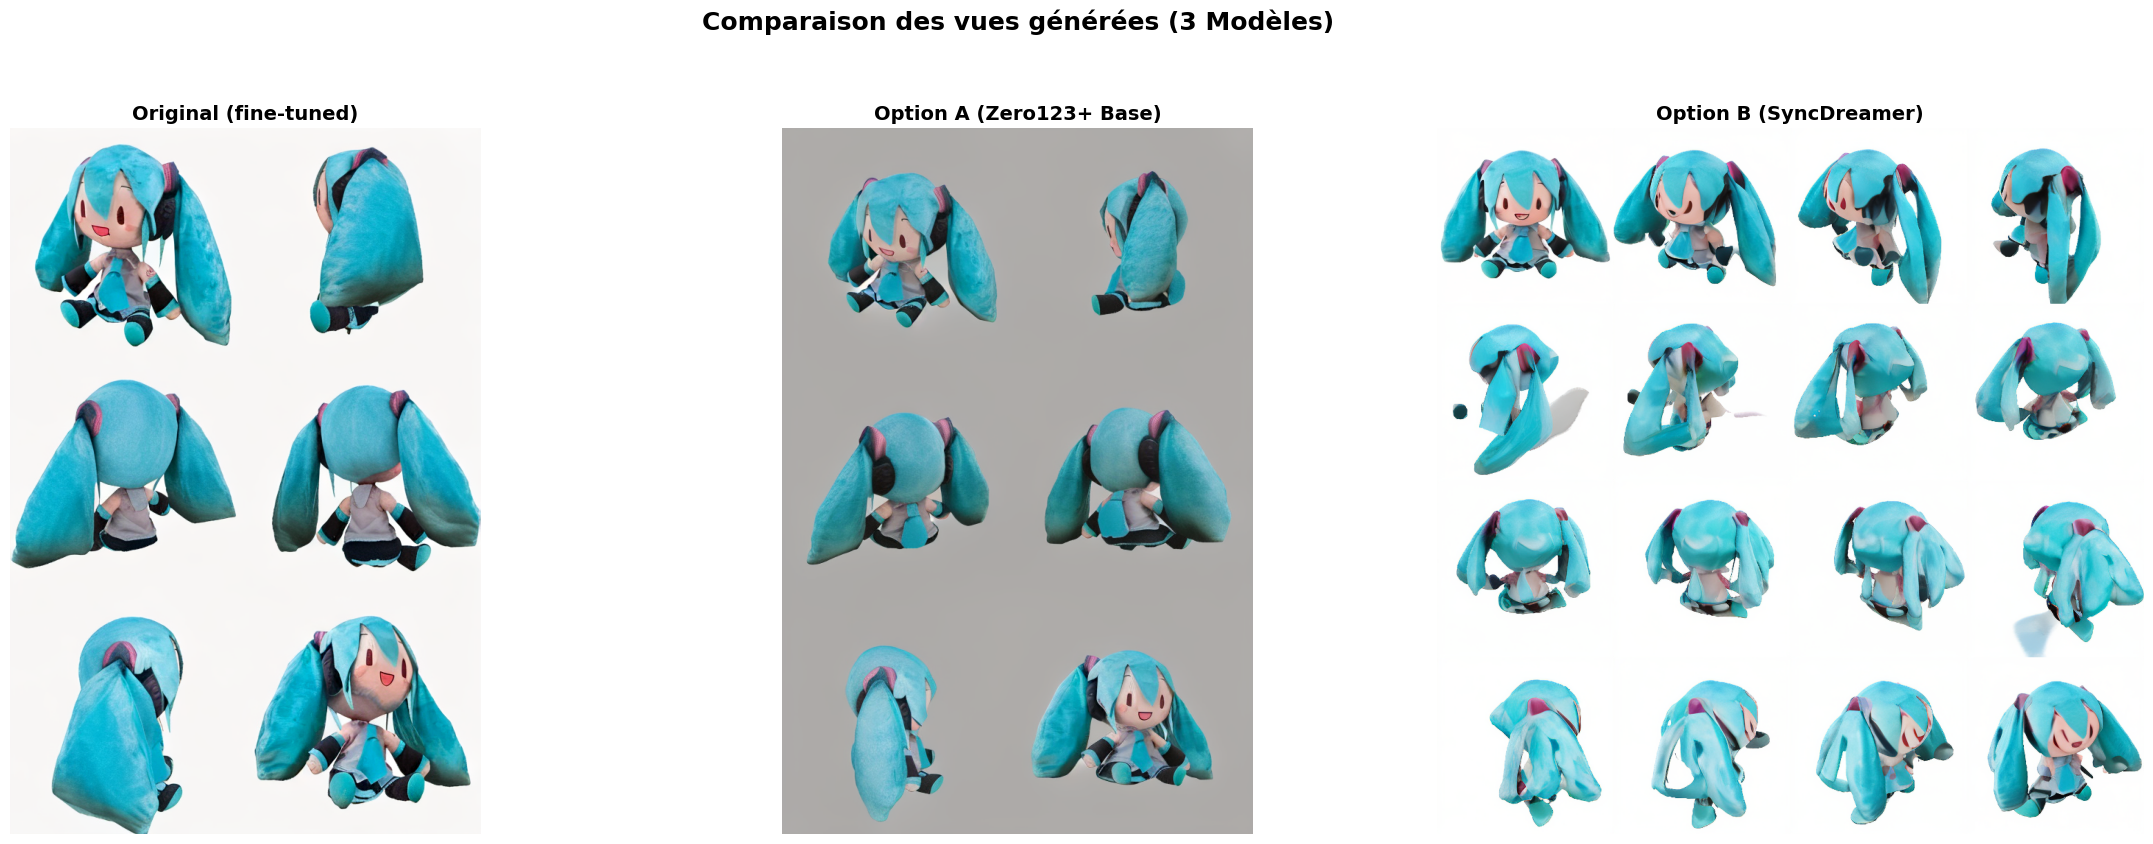


--- AFFICHAGE DES VIDÉOS ---

[OK] Modèle : Original (Fine-tuned)



[OK] Modèle : Option A (Base)



[OK] Modèle : Option B (SyncDreamer)


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Video
import os

# --- Vues multi-vues (Images) ---
# Note : Vérifie bien que les noms des dossiers correspondent à ceux créés lors de l'inférence
paths = {
    "Original (fine-tuned)": "outputs/instant-mesh-base_zero123plus_finetuned/images/hatsune_miku.png",
    "Option A (Zero123+ Base)": "outputs/instant-mesh-base_zero123plus_base/images/hatsune_miku.png",
    "Option B (SyncDreamer)": "/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/images/hatsune_miku_syncdreamer_grid.png",
}

# On passe à 1 ligne et 3 colonnes, et on augmente la largeur (figsize)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (label, path) in zip(axes, paths.items()):
    if os.path.exists(path):
        ax.imshow(np.array(Image.open(path)))
        ax.set_title(label, fontsize=14, fontweight='bold')
    else:
        ax.set_title(f"!!! FICHIER MANQUANT !!!\n{os.path.basename(path)}", color='red', fontsize=10)
        print(f"Attention : Image absente -> {path}")
    ax.axis('off')

plt.suptitle("Comparaison des vues générées (3 Modèles)", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

# Sauvegarde du comparatif
os.makedirs('outputs/comparaisons', exist_ok=True)
plt.savefig('outputs/comparaisons/comparaison_3_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Vidéos 3D ---
video_paths = {
    "Original (Fine-tuned)": "outputs/instant-mesh-base_zero123plus_finetuned/videos/hatsune_miku.mp4",
    "Option A (Base)": "outputs/instant-mesh-base_zero123plus_base/videos/hatsune_miku.mp4",
    "Option B (SyncDreamer)": "/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/videos/hatsune_miku.mp4",
}

print("\n--- AFFICHAGE DES VIDÉOS ---")
for label, path in video_paths.items():
    if os.path.exists(path):
        print(f"\n[OK] Modèle : {label}")
        display(Video(path, embed=True, width=512))
    else:
        print(f"[X] Vidéo manquante pour {label} : {path}")

In [15]:
import sys
sys.path.append('/usr/local/lib/python3.12/dist-packages')

In [16]:
!pip install -e git+https://github.com/CompVis/taming-transformers.git#egg=taming-transformers

Obtaining taming-transformers from git+https://github.com/CompVis/taming-transformers.git#egg=taming-transformers
  Cloning https://github.com/CompVis/taming-transformers.git to ./src/taming-transformers
  Running command git clone --filter=blob:none --quiet https://github.com/CompVis/taming-transformers.git /content/InstantMesh/src/taming-transformers
  Resolved https://github.com/CompVis/taming-transformers.git to commit 3ba01b241669f5ade541ce990f7650a3b8f65318
  Preparing metadata (setup.py) ... done
  Attempting uninstall: taming-transformers
    Found existing installation: taming-transformers 0.0.1
    Uninstalling taming-transformers-0.0.1:
      Successfully uninstalled taming-transformers-0.0.1
  Running setup.py develop for taming-transformers
